Name: Prajakta Mahangare

Roll No: 34

PRN NO.: 12520047

Class: CSE(AI)-SEDA Batch: B2

Assignment NO. 8  Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing details of customers to predict customer response for special offer. Create confusion matrix based on above data and find
Accuracy
Precision
Recall
F-1 score

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

Create Dataset

In [ ]:
data_dict = {
    "customer_id":[101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120],
    "age":[24,36,29,48,32,26,40,52,22,44,30,35,49,28,33,38,25,43,27,41],
    "gender":["Female","Male","Female","Male","Female","Male","Female","Male","Female","Male",
              "Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
    "income":[27000,58000,42000,78000,52000,31000,64000,87000,29000,69000,
              50000,54000,74000,33000,56000,62000,30000,71000,39000,66000],
    "price":[450,950,720,3100,420,820,520,5200,250,1100,
             620,370,4200,750,480,820,420,4700,580,920],
    "visit_frequency":[6,3,5,1,7,4,5,1,8,2,6,5,1,4,6,3,7,1,5,2],
    "previous_purchases":[3,1,4,0,5,2,4,1,6,1,4,3,0,2,4,1,5,0,3,1],
    "purchase":[1,0,1,0,1,0,1,0,1,0,1,1,0,1,1,0,1,0,1,0]
}

df = pd.DataFrame(data_dict)
df.head()

,customer_id,age,gender,income,price,visit_frequency,previous_purchases,purchase
0,101,24,Female,27000,450,6,3,1
1,102,36,Male,58000,950,3,1,0
2,103,29,Female,42000,720,5,4,1
3,104,48,Male,78000,3100,1,0,0
4,105,32,Female,52000,420,7,5,1


In [ ]:
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

Normalization / Feature Scaling

In [ ]:
scaler = StandardScaler()

features = ["age","income","price","visit_frequency","previous_purchases"]
df[features] = scaler.fit_transform(df[features])

df.head()

,customer_id,age,gender,income,price,visit_frequency,previous_purchases,purchase
0,101,-1.270003,0,-1.511656,-0.604788,0.868132,0.27735,1
1,102,0.102973,1,0.250048,-0.275920,-0.502603,-0.83205,0
2,103,-0.697930,0,-0.659219,-0.427200,0.411220,0.83205,1
3,104,1.475949,1,1.386632,1.138212,-1.416426,-1.38675,0
4,105,-0.354686,0,-0.090927,-0.624520,1.325044,1.38675,1


Single Predictor Logistic Model

In [ ]:
X_single = df[["income"]]
y = df["purchase"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y, test_size=0.3, random_state=42)

model_single = LogisticRegression()
model_single.fit(X_train_s, y_train_s)

y_pred_single = model_single.predict(X_test_s)

Confusion Matrix

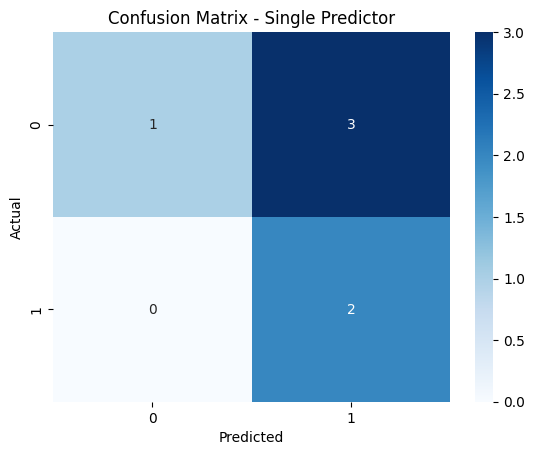

In [ ]:
cm_single = confusion_matrix(y_test_s, y_pred_single)

plt.figure()
sns.heatmap(cm_single, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Single Predictor")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Metrics

In [ ]:
print("Accuracy:", accuracy_score(y_test_s, y_pred_single))
print("Precision:", precision_score(y_test_s, y_pred_single))
print("Recall:", recall_score(y_test_s, y_pred_single))
print("F1 Score:", f1_score(y_test_s, y_pred_single))

Accuracy: 0.5
Precision: 0.4
Recall: 1.0
F1 Score: 0.5714285714285714


Multiple Predictor Model

In [ ]:
X_multi = df[["age","income","price","visit_frequency","previous_purchases","gender"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.3, random_state=42)

model_multi = LogisticRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_multi = model_multi.predict(X_test_m)

Confusion Matrix (Multiple Predictor)

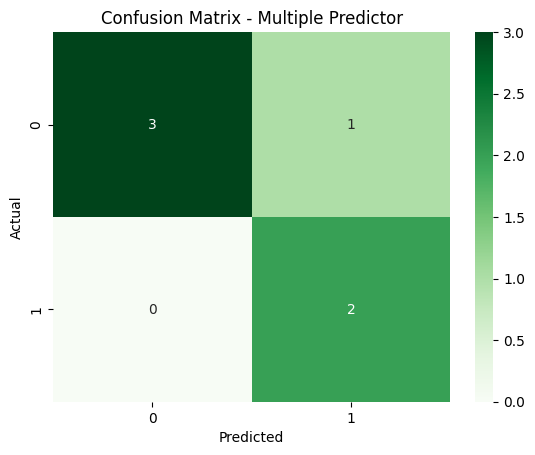

In [ ]:
cm_multi = confusion_matrix(y_test_m, y_pred_multi)

plt.figure()
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Multiple Predictor")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Metrics

In [ ]:
print("Accuracy:", accuracy_score(y_test_m, y_pred_multi))
print("Precision:", precision_score(y_test_m, y_pred_multi))
print("Recall:", recall_score(y_test_m, y_pred_multi))
print("F1 Score:", f1_score(y_test_m, y_pred_multi))

Accuracy: 0.8333333333333334
Precision: 0.6666666666666666
Recall: 1.0
F1 Score: 0.8


Coefficient Interpretation

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": model_multi.coef_[0]
})

print(coefficients)

              Feature  Coefficient
0                 age    -0.639455
1              income    -0.584839
2               price    -0.354603
3     visit_frequency     0.809781
4  previous_purchases     0.762755
5              gender    -0.277203


Model Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Single Model": [
        accuracy_score(y_test_s, y_pred_single),
        precision_score(y_test_s, y_pred_single),
        recall_score(y_test_s, y_pred_single),
        f1_score(y_test_s, y_pred_single)
    ],
    "Multiple Model": [
        accuracy_score(y_test_m, y_pred_multi),
        precision_score(y_test_m, y_pred_multi),
        recall_score(y_test_m, y_pred_multi),
        f1_score(y_test_m, y_pred_multi)
    ]
})

comparison

,Metric,Single Model,Multiple Model
0,Accuracy,0.500000,0.833333
1,Precision,0.400000,0.666667
2,Recall,1.000000,1.000000
3,F1 Score,0.571429,0.800000


Visual Comparison

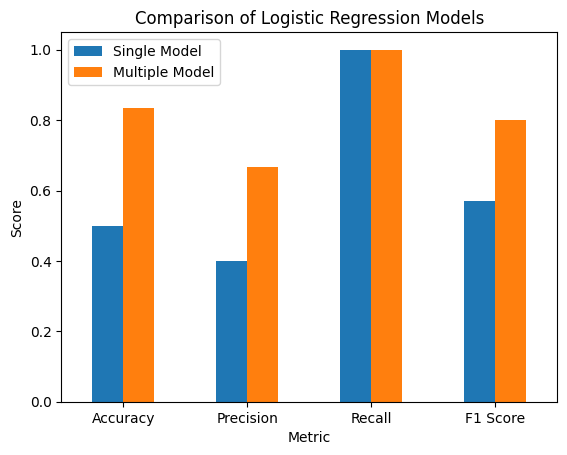

In [ ]:
comparison.set_index("Metric").plot(kind="bar")
plt.title("Comparison of Logistic Regression Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Sigmoid Curve

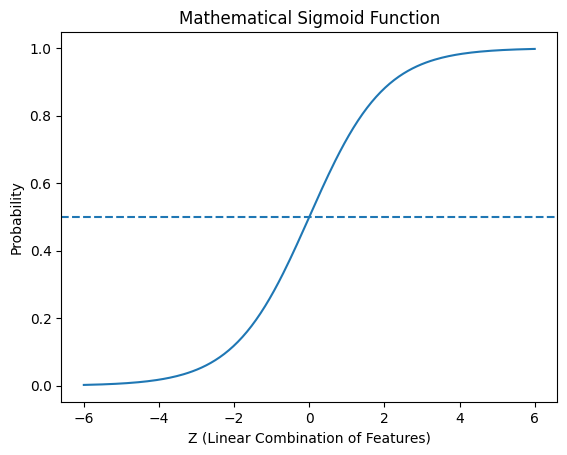

In [ ]:
X_range = np.linspace(-6, 6, 200)
y_sigmoid = 1 / (1 + np.exp(-X_range))

plt.figure()
plt.plot(X_range, y_sigmoid)
plt.axhline(0.5, linestyle='--')
plt.title("Mathematical Sigmoid Function")
plt.xlabel("Z (Linear Combination of Features)")
plt.ylabel("Probability")
plt.show()

In [ ]:
b0 = model_single.intercept_[0]
b1 = model_single.coef_[0][0]
decision_boundary = -b0 / b1

print("Decision Boundary (Income):", decision_boundary)

Decision Boundary (Income): 0.7058005285813137


Correlation Heatmap

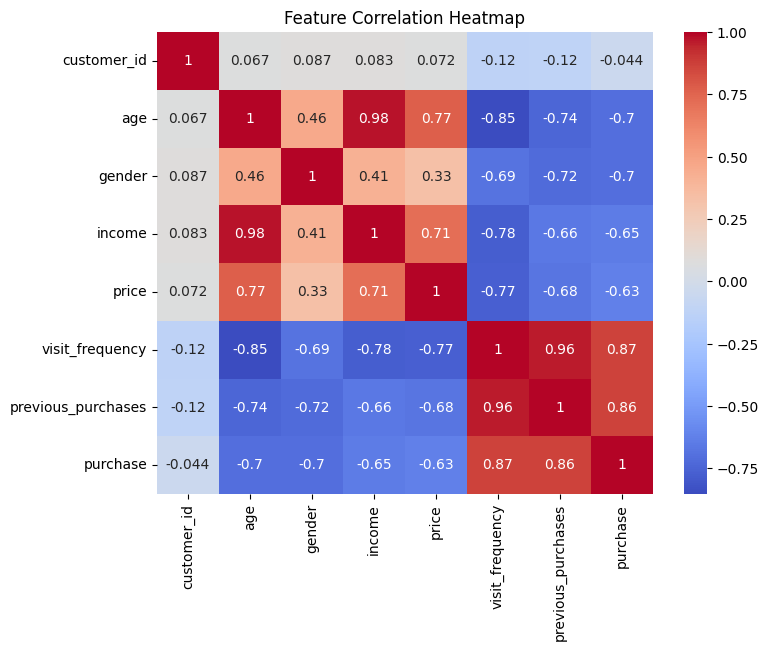

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Generate Synthetic Multiclass Data

In [ ]:
from sklearn.datasets import make_classification
import pandas as pd

X_mc, y_mc = make_classification(
    n_samples=150,
    n_features=5,
    n_classes=3,
    n_informative=4,
    n_redundant=0,
    random_state=42
)

df_multi = pd.DataFrame(X_mc, columns=["Feature1","Feature2","Feature3","Feature4","Feature5"])
df_multi["Target"] = y_mc

df_multi.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Target
0,-0.827040,-1.309666,1.185210,-1.806061,-1.806585,1
1,-2.760119,-0.406276,-1.334288,4.680379,-0.964572,2
2,1.361631,-2.877698,0.869740,1.242256,2.271752,2
3,0.120224,-3.309956,1.088540,-1.860570,1.121978,1
4,-0.465863,-1.016430,1.591717,-0.538683,-0.418926,0


Multiclass Classification

In [ ]:
X = df_multi.drop("Target", axis=1)
y = df_multi["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_mc = LogisticRegression(multi_class='multinomial', max_iter=200)
model_mc.fit(X_train, y_train)

y_pred_mc = model_mc.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multiclass Confusion Matrix

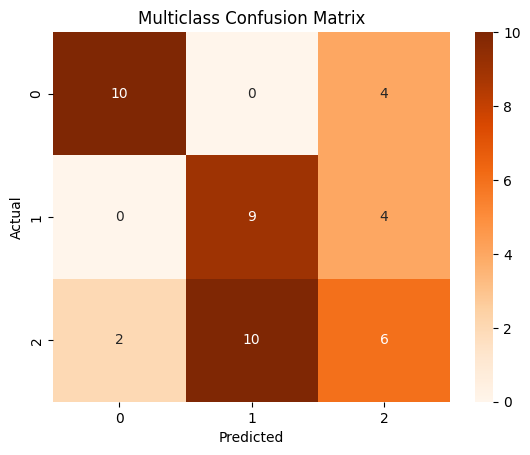

In [ ]:
cm_mc = confusion_matrix(y_test, y_pred_mc)

sns.heatmap(cm_mc, annot=True, fmt="d", cmap="Oranges")
plt.title("Multiclass Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()